# 04b · Kovaryans ve Korelasyon (Covariance & Correlation)
**Probability Lab** · Değişkenlerin Birlikte Hareketi

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Veri biliminin en hayati ve en çok yanlış anlaşılan konusuna geldik! İki değişken birlikte mi artıyor, ters mi hareket ediyor, yoksa alakaları yok mu?
> - **Kovaryans:** Yönü söyler (pozitif/negatif) ama büyüklüğü anlamsızdır.  
> - **Korelasyon (Pearson & Spearman):** Kovaryansın standardize edilmiş ([-1, 1] arasına sıkıştırılmış) halidir. Bize ilişkinin *gücünü* söyler.  
> - **Kritik Kural:** Korelasyon, nedensellik (causation) DEĞİLDİR!

**Önkoşul:** Ortak Dağılımlar (04a)  
**Veri:**  
- `anscombe` (Seaborn) — Sadece rakamlara güvenmemeyi öğreten o ünlü set
- `all_stocks_5yr.csv` — S&P 500 hisse senetleri (Finansal Kovaryans)
- `world_health_data.csv` — WHO Küresel Sağlık verileri (Sosyoekonomik Korelasyonlar)  
**Araçlar:** Python (pandas, seaborn), R (corrplot), SQL (DuckDB)

---
## 1 · Teorik Temeller: Matematik Bize Ne Diyor?

### 1.1 Kovaryans $Cov(X, Y)$

İki değişkenin ortalamalarından olan sapmalarının çarpımının beklenen değeridir:

$$Cov(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$$

- Eğer $X$ büyürken $Y$ de genelde büyüyorsa: Çarpım pozitif olur $\rightarrow Cov > 0$
- Eğer $X$ büyürken $Y$ genelde küçülüyorsa: Çarpım negatif olur $\rightarrow Cov < 0$
- Birbirlerinden bağımsızlarsa: $Cov = 0$

*Sorun:* Birimi tuhaftır! $X$ (Metre) ve $Y$ (Kilo) ise, Kovaryans birimi "Metre $\times$ Kilo" olur. Büyüklüğünün (örn: 500 mü, 0.5 mi) güçlü bir ilişki mi yoksa sadece ölçeğin mi büyük olduğunu bilemeyiz.

**Örneklem formülü (pratikte kullandığın hali):**

Yukarıdaki $Cov(X,Y)$ ve aşağıdaki $\rho_{X,Y}$ aslında **popülasyon parametreleri** — gerçek hayatta popülasyonun tamamına erişemezsin, elindeki veriyle bunların **tahminini** hesaplarsın. Bu tahmine örneklem istatistiği denir ve genelde $r$ ile gösterilir (popülasyon parametresi $\rho$'dan ayırt etmek için):

$$s_{XY} = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

Neden $n-1$ (n değil)? Çünkü $\bar{x}$ ve $\bar{y}$'nin kendisi de veriden tahmin edildiği için bir "serbestlik derecesi" kaybedilir (Bessel düzeltmesi). Raporlarken $\rho$ ile $r$'yi karıştırmamak önemli — $\rho$ teorik/popülasyon değeri, $r$ senin örneklemden hesapladığın değer.

---

### 1.2 Pearson Korelasyon Katsayısı ($\rho$ veya $r$)

Kovaryansı, iki değişkenin standart sapmalarına bölersek, birimlerden kurtuluruz!

$$\rho_{X,Y} = \frac{Cov(X, Y)}{\sigma_X \cdot \sigma_Y}$$

Örneklem üzerinden hesaplanan hali:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2}\sqrt{\sum(y_i-\bar{y})^2}}$$

- Her zaman **-1 ile +1** arasındadır.
- Sadece **Lineer (Doğrusal)** ilişkileri ölçer! Eğrisel (U-şekli) bir ilişki varsa $r=0$ çıkabilir.

**Sayısal örnek:** 5 öğrencinin ders çalışma saati ($X$) ve sınav notu ($Y$) şöyle olsun:

| Öğrenci | X (saat) | Y (not) |
|---|---|---|
| 1 | 2 | 50 |
| 2 | 4 | 60 |
| 3 | 6 | 70 |
| 4 | 8 | 85 |
| 5 | 10 | 95 |

$\bar{x}=6$, $\bar{y}=72$. Sapmalar: $(x_i-\bar{x}) = [-4,-2,0,2,4]$, $(y_i-\bar{y}) = [-22,-12,-2,13,23]$.

Pay: $(-4)(-22)+(-2)(-12)+0+2(13)+4(23) = 88+24+0+26+92 = 230$

Payda: $\sqrt{(-4)^2+(-2)^2+0^2+2^2+4^2}\times\sqrt{(-22)^2+(-12)^2+(-2)^2+13^2+23^2} = \sqrt{40}\times\sqrt{1206} \approx 6.32\times34.73 \approx 219.5$

$$r = \frac{230}{219.5} \approx 0.995$$

Neredeyse mükemmel pozitif lineer ilişki — beklendiği gibi, çünkü veriyi zaten güçlü lineer bir örüntüyle kurguladık.

---

### 1.3 Spearman Sıra Korelasyonu

Verinin gerçek değerlerine değil, **sıralamalarına (rank)** bakar.

Örneğin gelir (Log-Normal, uç değerler çok) ile sağlık arasındaki ilişkiye bakarken, uç değerlerin (milyarderlerin) Pearson'ı bozmaması için kullanılır. Lineer olmak zorunda değildir, sadece "Biri artarken diğeri de istikrarlı şekilde artıyor mu?" sorusuna (Monotonik ilişki) yanıt verir.

**Formül:** Spearman aslında sıralanmış (rank'lenmiş) verilere Pearson formülünün uygulanmış hali. Bağ (tie) yoksa şu kısayol formülü kullanılır:

$$\rho_s = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$$

Burada $d_i$, iki değişkendeki $i$. gözlemin sıralama farkı ($d_i = \text{rank}(x_i) - \text{rank}(y_i)$).

**Sayısal örnek:** $X=[10, 20, 30, 40, 50]$ (normal artan) ile $Y=[100, 90, 400, 300, 1000]$ (lineer değil ama monotonik artan) değişkenlerini karşılaştıralım.

| $x_i$ | rank($x_i$) | $y_i$ | rank($y_i$) | $d_i$ | $d_i^2$ |
|---|---|---|---|---|---|
| 10 | 1 | 100 | 2 | -1 | 1 |
| 20 | 2 | 90 | 1 | 1 | 1 |
| 30 | 3 | 400 | 4 | -1 | 1 |
| 40 | 4 | 300 | 3 | 1 | 1 |
| 50 | 5 | 1000 | 5 | 0 | 0 |

$\sum d_i^2 = 4$, $n=5$:

$$\rho_s = 1 - \frac{6(4)}{5(25-1)} = 1 - \frac{24}{120} = 1 - 0.2 = 0.8$$

Pearson'ı bu veriyle hesaplasan muhtemelen daha düşük çıkardı çünkü $Y$'deki sıçramalar (özellikle 1000) lineerliği bozuyor — ama Spearman, sıralamaya baktığı için ilişkinin gerçekten güçlü ve tutarlı (monotonik) olduğunu doğru yakalıyor.

---

### 1.4 Altın Kural: Anscombe'un Dörtlüsü ve Nedensellik

![img](/Users/melih/PycharmProjects/DS-Mastery-Journey/probability-lab/04_joint_distributions/data/ansquad.svg)

Veri görselleştirilmeden korelasyon katsayısına asla güvenilmez. İki değişkenin çok yüksek korelasyona sahip olması, birinin diğerine sebep olduğunu göstermez (*Spurious Correlation - Sahte Korelasyon*). (Örn: Dondurma satışları ile denizde boğulma vakaları arasında mükemmel korelasyon vardır. Sebebi yaz mevsimidir - *Confounding Variable*).

**Anscombe'un Dörtlüsü nedir (örnek):** İstatistikçi Francis Anscombe'un 1973'te oluşturduğu 4 farklı veri seti — hepsinin ortalaması, varyansı, Pearson $r$'si ($\approx 0.816$) ve regresyon doğrusu neredeyse birebir aynı, ama saçılım grafiğine (scatter plot) bakınca dördü de tamamen farklı görünüyor:

1. **Set I:** Gerçek, düzgün lineer ilişki — $r$'nin doğru yansıttığı "normal" durum.
2. **Set II:** Belirgin bir eğrisel (kuadratik) örüntü — Pearson bunu "lineer ilişki" gibi raporluyor ama aslında ilişki eğrisel, $r$ yanıltıcı.
3. **Set III:** Neredeyse mükemmel bir doğru + tek bir aykırı değer (outlier) — o tek nokta olmasa $r=1.0$ olurdu, outlier korelasyonu düşürüyor.
4. **Set IV:** Verinin neredeyse tamamı tek bir $x$ değerinde dikey bir çizgi + tek bir uç nokta o "ilişkiyi" yapay olarak yaratıyor — gerçekte $X$ ile $Y$ arasında anlamlı bir ilişki yok.

Bu dörtlünün mesajı: **aynı $r$ değeri, tamamen farklı hikayeleri gizleyebilir.** Bu yüzden korelasyon raporlamadan önce mutlaka scatter plot çizmek gerekiyor.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Python Hazir ✓')


Python Hazir ✓


---
### 🔴 Python 1 — İstatistiğin En Önemli Dersi: Anscombe Quartet

1973'te istatistikçi Francis Anscombe tarafından, sadece sayılara (ortalama, varyans, korelasyon) güvenmenin ne kadar tehlikeli olduğunu kanıtlamak için yaratılan 4 veri setidir.

=== Anscombe Veri Setlerinin İstatistiksel Özellikleri ===
Set I: Mean X=9.00, Mean Y=7.50, Std X=3.32, Std Y=2.03 | Korelasyon (r)=0.816
Set II: Mean X=9.00, Mean Y=7.50, Std X=3.32, Std Y=2.03 | Korelasyon (r)=0.816
Set III: Mean X=9.00, Mean Y=7.50, Std X=3.32, Std Y=2.03 | Korelasyon (r)=0.816
Set IV: Mean X=9.00, Mean Y=7.50, Std X=3.32, Std Y=2.03 | Korelasyon (r)=0.817

İNANILMAZ! 4 Veri setinin de ortalaması, standart sapması ve korelasyonu BİREBİR AYNI!
Peki bu veriler aynı mı? Çizelim:


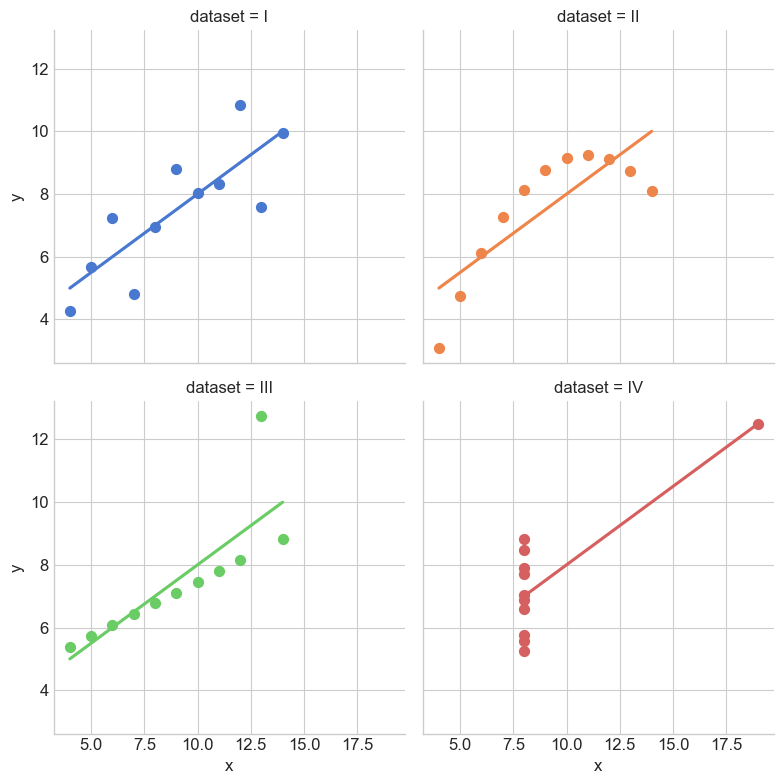

YORUM:
- I: Normal, doğrusal bir ilişki.
- II: Kusursuz bir ilişki var ama DOĞRUSAL DEĞİL (Eğrisel). Pearson korelasyonu eğrileri yakalayamaz!
- III: Mükemmel doğrusal bir ilişki var ama tek bir AYKIRI DEĞER (Outlier) korelasyonu aşağı çekmiş.
- IV: Aslında X ile Y arasında HİÇBİR ilişki yok (X hep 8). Ancak tek bir outlier korelasyonu 0.816'ya uçurmuş!

DERS: Veriyi çizmeden korelasyon hesaplamak cinayettir.


In [2]:
anscombe = sns.load_dataset('anscombe')

print("=== Anscombe Veri Setlerinin İstatistiksel Özellikleri ===")
for dataset in ['I', 'II', 'III', 'IV']:
    subset = anscombe[anscombe['dataset'] == dataset]
    mean_x = subset['x'].mean()
    mean_y = subset['y'].mean()
    std_x = subset['x'].std()
    std_y = subset['y'].std()
    corr = subset['x'].corr(subset['y'])
    print(f"Set {dataset}: Mean X={mean_x:.2f}, Mean Y={mean_y:.2f}, Std X={std_x:.2f}, Std Y={std_y:.2f} | Korelasyon (r)={corr:.3f}")

print("\nİNANILMAZ! 4 Veri setinin de ortalaması, standart sapması ve korelasyonu BİREBİR AYNI!")
print("Peki bu veriler aynı mı? Çizelim:")

sns.lmplot(x="x", y="y", col="dataset", hue="dataset", data=anscombe, 
           col_wrap=2, ci=None, palette="muted", height=4, scatter_kws={"s": 50, "alpha": 1})
plt.show()

print("YORUM:")
print("- I: Normal, doğrusal bir ilişki.")
print("- II: Kusursuz bir ilişki var ama DOĞRUSAL DEĞİL (Eğrisel). Pearson korelasyonu eğrileri yakalayamaz!")
print("- III: Mükemmel doğrusal bir ilişki var ama tek bir AYKIRI DEĞER (Outlier) korelasyonu aşağı çekmiş.")
print("- IV: Aslında X ile Y arasında HİÇBİR ilişki yok (X hep 8). Ancak tek bir outlier korelasyonu 0.816'ya uçurmuş!")
print("\nDERS: Veriyi çizmeden korelasyon hesaplamak cinayettir.")


---
### 📈 Python 2 — Finansal Verilerde Kovaryans ve Korelasyon Matrisi

Finansta portföy yaparken aynı yöne giden (yüksek korele) hisseleri almaktan kaçınırız (riski dağıtmak için). Bakalım teknoloji devleri birbirleriyle nasıl hareket ediyor.

=== GÜNLÜK GETİRİ KOVARYANS MATRİSİ ===
Name       AAPL      AMZN     GOOGL
Name                               
AAPL   2.129560  0.765463  0.706596
AMZN   0.765463  3.325074  1.388015
GOOGL  0.706596  1.388015  1.926442

(Kovaryansin birimi getiri^2 oldugu icin yorumlamasi cok zor. Bu yuzden korelasyona geceriz)

=== GÜNLÜK GETİRİ PEARSON KORELASYON MATRİSİ ===
Name       AAPL      AMZN     GOOGL
Name                               
AAPL   1.000000  0.287659  0.348858
AMZN   0.287659  1.000000  0.548423
GOOGL  0.348858  0.548423  1.000000


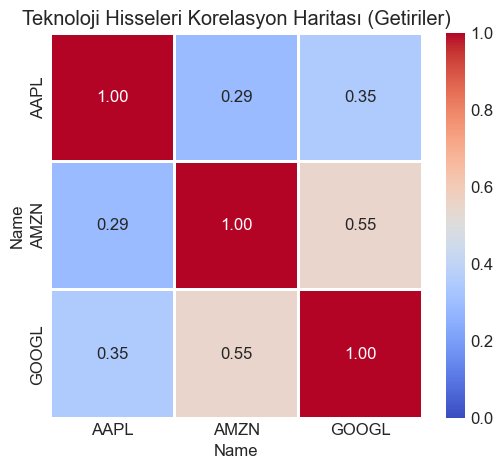

YORUM:
- GOOGL ile AMZN arasindaki korelasyon (0.55) yüksek. Biri yukari cikarsa digeri de genelde cikar.
- Bu deger 1'e ne kadar yakinsa o kadar paralel hareket ederler.


In [4]:
stocks = pd.read_csv('data/all_stocks_5yr.csv', parse_dates=['date'])

# Sadece Apple, Google (Alphabet) ve Amazon'u alalim
tech_stocks = stocks[stocks['Name'].isin(['AAPL', 'GOOGL', 'AMZN'])]

# Pivot tablo: Her tarih bir satir, her hisse bir sutun (Kapanis fiyatlari)
pivot_df = tech_stocks.pivot(index='date', columns='Name', values='close')

# Fiyatlarin korelasyonuna bakmak yanilticidir (zamanla hepsi artar). 
# GÜNLÜK YÜZDE GETİRİLERİ (Daily Returns) bulmaliyiz!
returns = pivot_df.pct_change().dropna()

# 1. Kovaryans Matrisi
cov_matrix = returns.cov()
print("=== GÜNLÜK GETİRİ KOVARYANS MATRİSİ ===")
print(cov_matrix * 10000) # Okunabilirlik icin 10000 ile carptik
print("\n(Kovaryansin birimi getiri^2 oldugu icin yorumlamasi cok zor. Bu yuzden korelasyona geceriz)")

# 2. Korelasyon Matrisi
corr_matrix = returns.corr()
print("\n=== GÜNLÜK GETİRİ PEARSON KORELASYON MATRİSİ ===")
print(corr_matrix)

# Heatmap cizimi
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f", linewidths=1)
plt.title('Teknoloji Hisseleri Korelasyon Haritası (Getiriler)')
plt.show()

print("YORUM:")
print("- GOOGL ile AMZN arasindaki korelasyon (0.55) yüksek. Biri yukari cikarsa digeri de genelde cikar.")
print("- Bu deger 1'e ne kadar yakinsa o kadar paralel hareket ederler.")


---
### 🌍 Python 3 — Sağlık Verisi: Pearson vs Spearman

Dünya Sağlık Örgütü (WHO) verisinde, Yaşam Beklentisi (`life_expect`) ile diğer metriklerin korelasyonuna bakacağız.

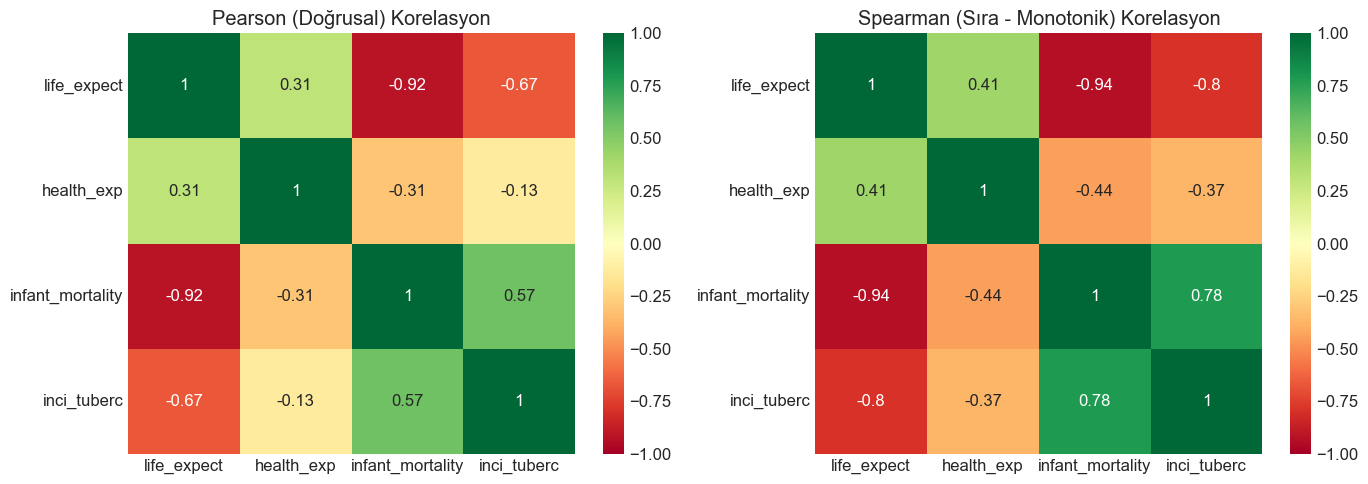

=== NEDEN FARKLI ÇIKTILAR? ===
Özellikle 'life_expect' (Yaşam Süresi) ile 'health_exp' (Sağlık Harcaması) arasındaki ilişkiye bakın:
Pearson: 0.306
Spearman: 0.415

Sebebi görmek için grafiğini çizelim:


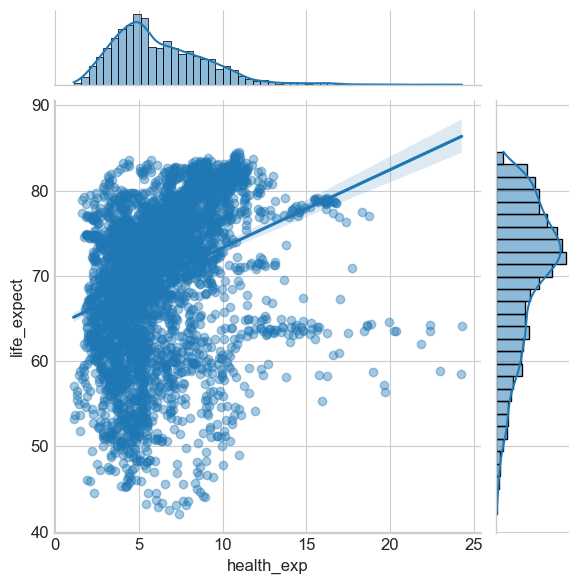

YORUM: Sağlık harcaması Log-Normal dağılıyor (çok büyük uç değerler var). İlişki bir noktadan sonra doygunluğa ulaşıyor (Eğrisel / Logaritmik).
Pearson düz çizgi uydurmaya çalıştığı için ilişkiyi DÜŞÜK buluyor. Spearman ise sıralamaya baktığı için gerçek (ve çok güçlü) ilişkiyi yakalıyor!


In [5]:
who_df = pd.read_csv('data/world_health_data.csv')

# Inceleyecegimiz bazi kolonlar
cols = ['life_expect', 'health_exp', 'infant_mortality', 'inci_tuberc']
subset = who_df[cols].dropna()

# Pearson ve Spearman korelasyonlarini hesapla
pearson_corr = subset.corr(method='pearson')
spearman_corr = subset.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pearson_corr, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson (Doğrusal) Korelasyon')

sns.heatmap(spearman_corr, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman (Sıra - Monotonik) Korelasyon')
plt.tight_layout()
plt.show()

print("=== NEDEN FARKLI ÇIKTILAR? ===")
print("Özellikle 'life_expect' (Yaşam Süresi) ile 'health_exp' (Sağlık Harcaması) arasındaki ilişkiye bakın:")
print(f"Pearson: {pearson_corr.loc['life_expect', 'health_exp']:.3f}")
print(f"Spearman: {spearman_corr.loc['life_expect', 'health_exp']:.3f}")

print("\nSebebi görmek için grafiğini çizelim:")
sns.jointplot(data=subset, x='health_exp', y='life_expect', kind='reg', scatter_kws={'alpha':0.4})
plt.show()

print("YORUM: Sağlık harcaması Log-Normal dağılıyor (çok büyük uç değerler var). İlişki bir noktadan sonra doygunluğa ulaşıyor (Eğrisel / Logaritmik).")
print("Pearson düz çizgi uydurmaya çalıştığı için ilişkiyi DÜŞÜK buluyor. Spearman ise sıralamaya baktığı için gerçek (ve çok güçlü) ilişkiyi yakalıyor!")


---
# 📊 R Uygulaması: corrplot ile Görsel Şölen

R'daki `corrplot` paketi, çok değişkenli korelasyonları tek bakışta anlamak için muazzam bir araçtır.

In [6]:
%load_ext rpy2.ipython


Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


`geom_smooth()` using formula = 'y ~ x'


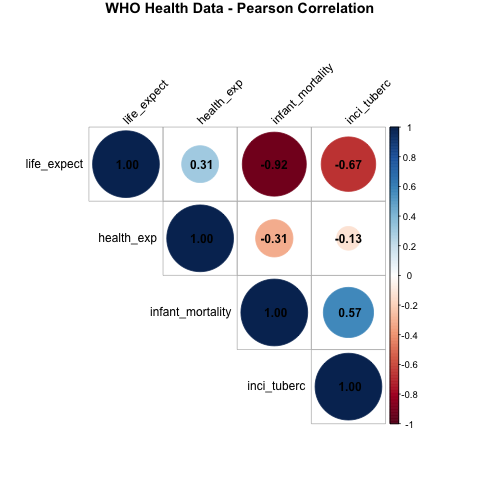

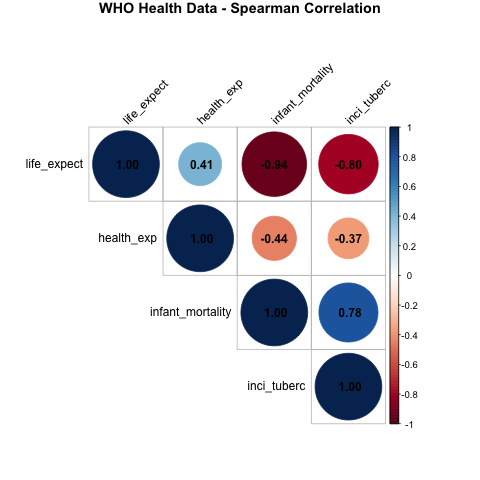

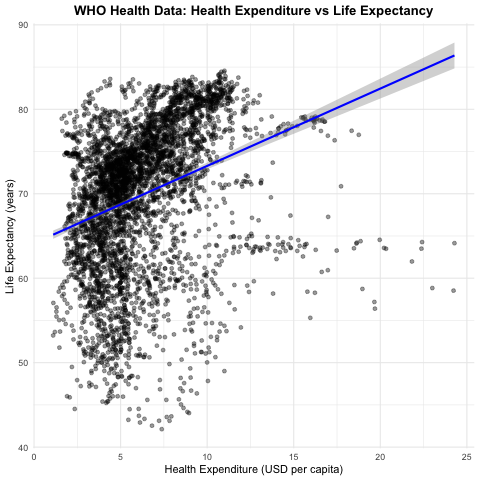

In [18]:
%%R -i subset

#install.packages("corrplot") #calistirmasi gerekebilir
library(corrplot)
library(ggplot2)

P <- cor(subset, use="complete.obs", method="pearson")
S <- cor(subset, use="complete.obs", method="spearman")

# Dairelerin büyüklüğü ve rengi korelasyonun gücünü gösterir
corrplot(P, method="circle", type="upper", 
         tl.col="black", tl.srt=45, 
         addCoef.col = "black", # Icine rakamlari da yaz
         title="WHO Health Data - Pearson Correlation",
         mar=c(0,0,1,0))

corrplot(S, method="circle", type="upper",
         tl.col="black", tl.srt=45,
         addCoef.col = "black",
         title="WHO Health Data - Spearman Correlation",
         mar=c(0,0,1,0))

j <- ggplot(subset, aes(x=health_exp, y=life_expect)) +
    geom_point(alpha=0.4) +
    geom_smooth(method='lm', color='blue') +
    labs(title="WHO Health Data: Health Expenditure vs Life Expectancy",
            x="Health Expenditure (USD per capita)",
            y="Life Expectancy (years)") +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5, face="bold"))

print(j)


---
# 🗄️ SQL Uygulaması (DuckDB): El Hesabı vs Fonksiyon

Modern veritabanlarında `CORR(X, Y)` fonksiyonu bulunur. Ancak bu fonksiyonun arka planda ne yaptığını (Kovaryans formulü üzerinden) manuel olarak kodlamak, istatistiği anlamanın en iyi yoludur.

In [19]:
import duckdb
con = duckdb.connect()
con.register('health_tbl', who_df.dropna(subset=['life_expect', 'infant_mortality']))
print('DuckDB hazir ✓')


DuckDB hazir ✓


In [25]:
sql_query = """
WITH ranked_health AS (
    SELECT 
        life_expect,
        infant_mortality,
        -- Spearman için sıralama (rank) hesapları
        RANK() OVER (ORDER BY life_expect) AS rank_life_expect,
        RANK() OVER (ORDER BY infant_mortality) AS rank_infant_mortality,
        -- Manuel kovaryans ve korelasyon için genel ortalamalar
        AVG(life_expect) OVER () AS avg_life,
        AVG(infant_mortality) OVER () AS avg_infant
    FROM health_tbl
)
SELECT 
    COUNT(*) as N,
    
    -- 1. SQL Hazır Fonksiyon (Pearson Korelasyonu)
    ROUND(CORR(life_expect, infant_mortality), 4) AS hazir_corr,
    
    -- 2. SQL Hazır Fonksiyon (Kovaryans)
    ROUND(COVAR_POP(life_expect, infant_mortality), 4) AS hazir_cov,

    -- 3. Doğrulanan Manuel Fonksiyon (Spearman Korelasyonu)
    ROUND(CORR(rank_life_expect, rank_infant_mortality), 4) AS spearman_corr,
    
    -- 4. MANUEL KOVARYANS: E[ (X - E[X]) * (Y - E[Y]) ]
    -- (Performans için alt sorgular yerine pencere fonksiyonu ortalamaları kullanıldı)
    ROUND(
        AVG((life_expect - avg_life) * (infant_mortality - avg_infant)),
    4) AS manuel_cov,
    
    -- 5. MANUEL KORELASYON: Cov / (StdX * StdY)
    ROUND(
        AVG((life_expect - avg_life) * (infant_mortality - avg_infant)) 
        / (STDDEV_POP(life_expect) * STDDEV_POP(infant_mortality)),
    4) AS manuel_corr
    
FROM ranked_health;
"""

df_sql = con.execute(sql_query).df()
print("=== Bebek Ölüm Oranı vs Yaşam Beklentisi Korelasyonu ===")
print(df_sql.T)

print("\nYORUM: Hem Kovaryans hem de Korelasyonu el ile SQL'in standart toplayıcı fonksiyonlarıyla birebir üretebiliyoruz. ")


=== Bebek Ölüm Oranı vs Yaşam Beklentisi Korelasyonu ===
                       0
N              5762.0000
hazir_corr       -0.9220
hazir_cov      -202.3392
spearman_corr    -0.9379
manuel_cov     -202.3392
manuel_corr      -0.9220

YORUM: Hem Kovaryans hem de Korelasyonu el ile SQL'in standart toplayıcı fonksiyonlarıyla birebir üretebiliyoruz. 


---
## ✏️ Egzersizler 

### E1 — Anscombe'da Saklı Gerçekler
a) Anscombe'un 4 setini de kullanarak, `x` ve `y` arasındaki **Spearman** korelasyonunu hesapla (Python'da). Pearson'da hepsi 0.816 çıkmıştı. Spearman'da Set I, II, III ve IV için hangi değerleri alıyorsun? Özellikle Outlier olan Set III'te sıra (rank) korelasyonunun direncini görebiliyor musun?

b) Veri seti II için, y = $ax^2 + bx + c$ formunda bir polinom uydurmayı dene (`np.polyfit`). Korelasyon (r) düz bir çizgi aradığı için başarısız olmuştu. Polinom eğrisinin veriye ne kadar iyi oturduğunu (örn: $R^2$ değeri ile) tartış.


 === Egzersiz 1: Anscombe Veri Setleri ===

 === E1a - Her veri seti için ortalama, standart sapma ve korelasyonu hesaplayın. (Pearson ve Spearman) ===
Set I: Mean X=9.00, Mean Y=7.50, Std X=3.32, Std Y=2.03 | Korelasyon (Pearson)(r)=0.816, Korelasyon (Spearman)(r)=0.818
Set II: Mean X=9.00, Mean Y=7.50, Std X=3.32, Std Y=2.03 | Korelasyon (Pearson)(r)=0.816, Korelasyon (Spearman)(r)=0.691
Set III: Mean X=9.00, Mean Y=7.50, Std X=3.32, Std Y=2.03 | Korelasyon (Pearson)(r)=0.816, Korelasyon (Spearman)(r)=0.991
Set IV: Mean X=9.00, Mean Y=7.50, Std X=3.32, Std Y=2.03 | Korelasyon (Pearson)(r)=0.817, Korelasyon (Spearman)(r)=0.500

 === E1b - Veri seti II için polinom regresyonu ===


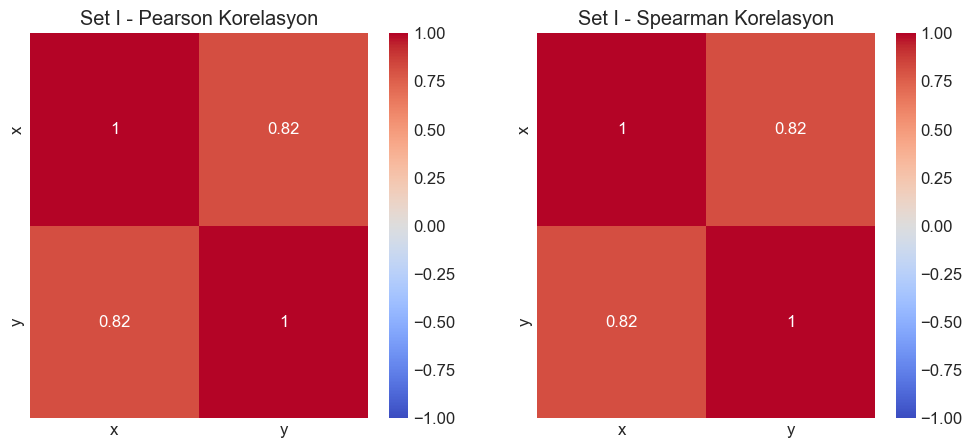

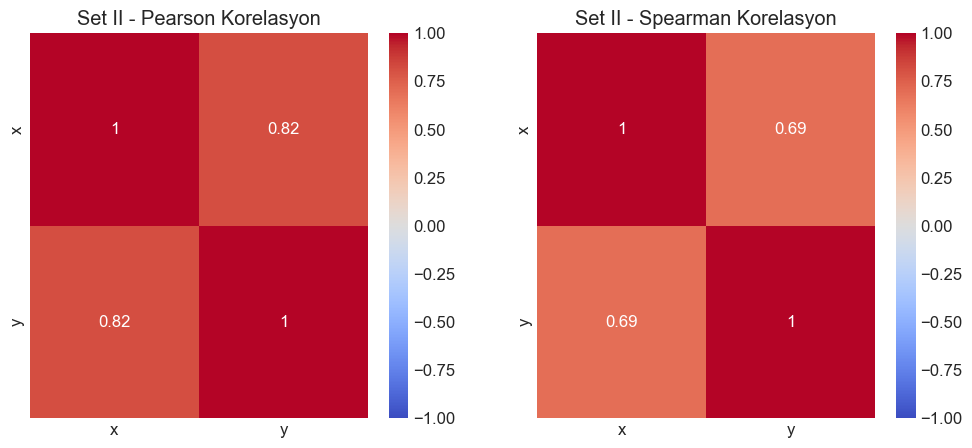

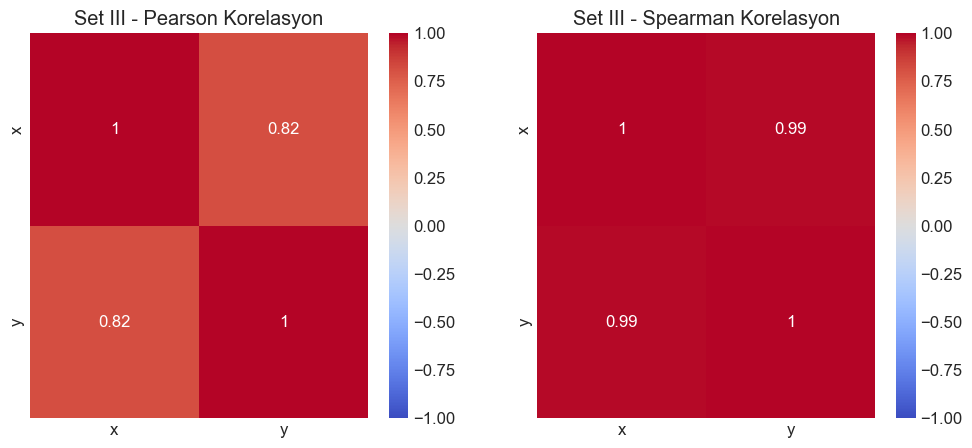

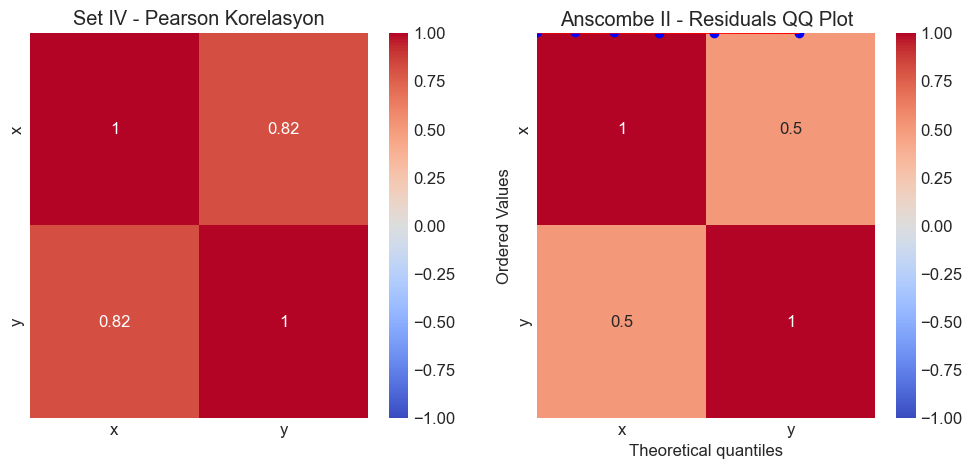

Set II için polinom regresyon katsayıları: [-0.12671329  2.78083916 -5.99573427]


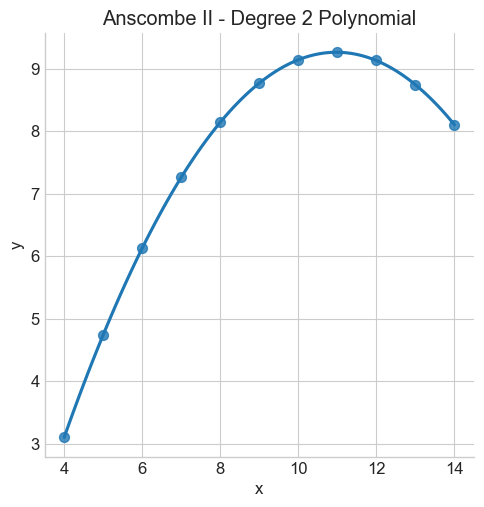

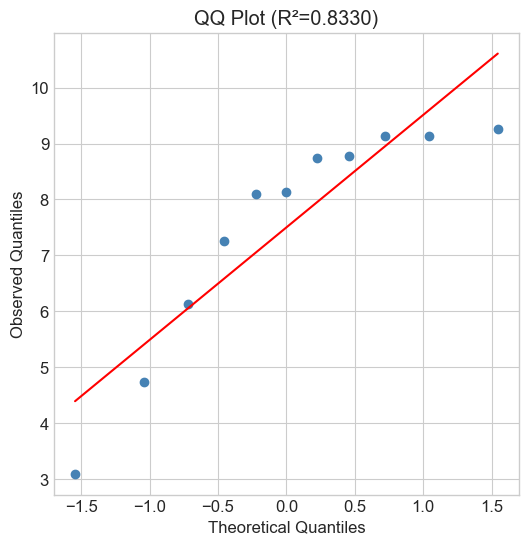

In [51]:
print("\n === Egzersiz 1: Anscombe Veri Setleri ===")
print("\n === E1a - Her veri seti için ortalama, standart sapma ve korelasyonu hesaplayın. (Pearson ve Spearman) ===")
anscombe = sns.load_dataset('anscombe')
for dataset in ['I', 'II', 'III', 'IV']:
    subset = anscombe[anscombe['dataset'] == dataset]
    mean_x = subset['x'].mean()
    mean_y = subset['y'].mean()
    std_x = subset['x'].std()
    std_y = subset['y'].std()
    pearson_corr = subset['x'].corr(subset['y'])
    spearman_corr = subset['x'].rank().corr(subset['y'].rank())
    print(f"Set {dataset}: Mean X={mean_x:.2f}, Mean Y={mean_y:.2f}, Std X={std_x:.2f}, Std Y={std_y:.2f} | Korelasyon (Pearson)(r)={pearson_corr:.3f}, Korelasyon (Spearman)(r)={spearman_corr:.3f}")
    cols = ['x', 'y']
    subset = subset[cols]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax1 = axes[0]
    ax2 = axes[1]
    ax1.set_title(f"Set {dataset} - Pearson Korelasyon")
    ax2.set_title(f"Set {dataset} - Spearman Korelasyon")
    sns.heatmap(subset.corr(method='pearson'), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax1)
    sns.heatmap(subset.corr(method='spearman'), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax2)

print("\n === E1b - Veri seti II için polinom regresyonu ===")

anscombe_II = anscombe[anscombe['dataset'] == 'II']
polinom = np.polyfit(anscombe_II['x'], anscombe_II['y'], deg=2)
y_hat = np.polyval(polinom, anscombe_II['x'])
residuals = anscombe_II['y'] - y_hat

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Anscombe II - Residuals QQ Plot")
plt.show()
print(f"Set II için polinom regresyon katsayıları: {polinom}")

sns.lmplot(
    x="x",
    y="y",
    data=anscombe_II,
    order=2,
    ci=None,
    scatter_kws={"s":50}
)

plt.title("Anscombe II - Degree 2 Polynomial")
plt.show()
(osm, osr), (slope, intercept, r) = stats.probplot(
    anscombe_II["y"],
    dist="norm",
    fit=True
)

plt.figure(figsize=(6,6))

plt.scatter(osm, osr, color="steelblue")

plt.plot(
    osm,
    slope*np.array(osm)+intercept,
    color="red"
)

plt.title(f"QQ Plot (R²={r**2:.4f})")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Observed Quantiles")

plt.show()

---
### E2 — Hisse Senetleri ve Portföy Mantığı
a) `all_stocks_5yr.csv` içinden SADECE Coca Cola (KO) ve Pepsi (PEP) hisselerini seçerek GÜNLÜK YÜZDE GETİRİ (daily return) sütunları oluştur. Bu iki hissenin arasındaki Pearson korelasyonunu bul. 

b) Geçmiş derslerde gördüğümüz $Var(X+Y) = Var(X) + Var(Y) + 2Cov(X,Y)$ kuralını hatırla. Eğer portföyünüze birbiriyle ÇOK YÜKSEK korele (örneğin $r=0.9$) hisseler koyarsanız, portföyünüzün toplam varyansı (yani riski) artar mı azalır mı? Kendi kelimelerinle "Diversification" (Çeşitlendirme) nedir açıkla.


 === Egzersiz  2: Teknoloji Hisseleri ===

 === E2a - KO ve PEP hisselerini seç günlük yüzde getiri sütınu oluştur ve Pearson korelasyonunu hesapla ===
=== KO ve PEP Hisseleri Günlük Getiri Korelasyon Matrisi ===


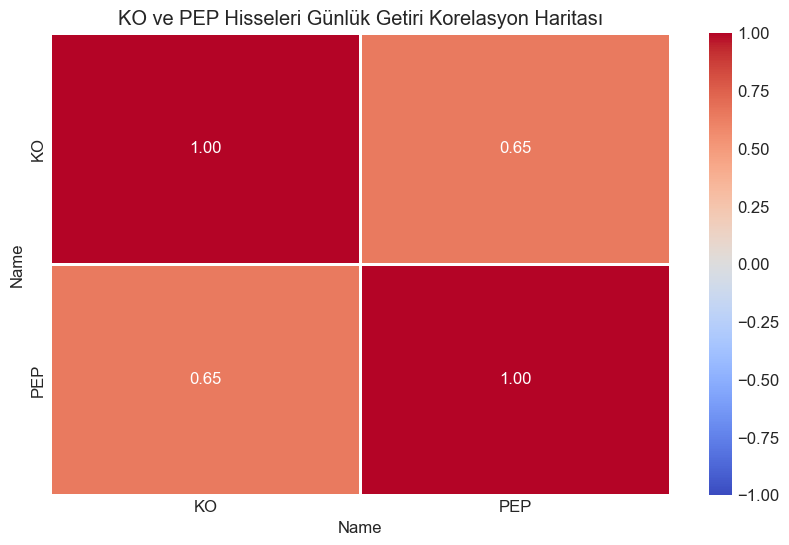

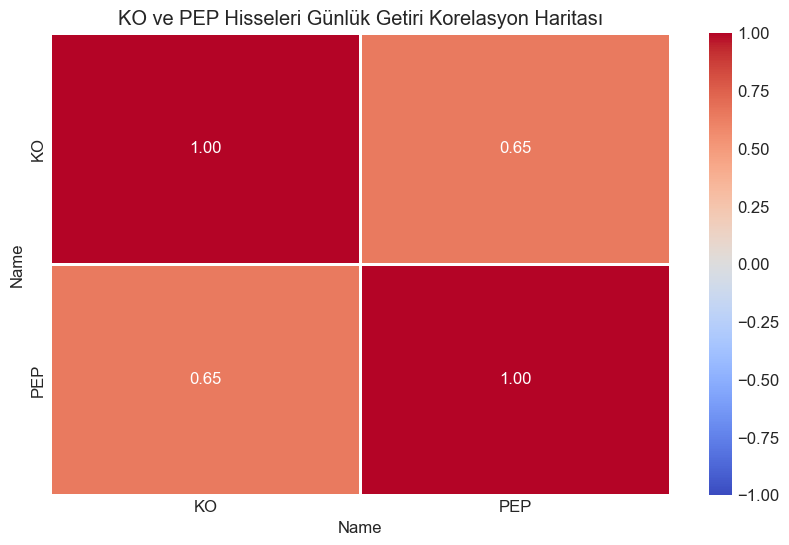

=== KO ve PEP Hisseleri Günlük Getiri Spearman Korelasyon Matrisi ===


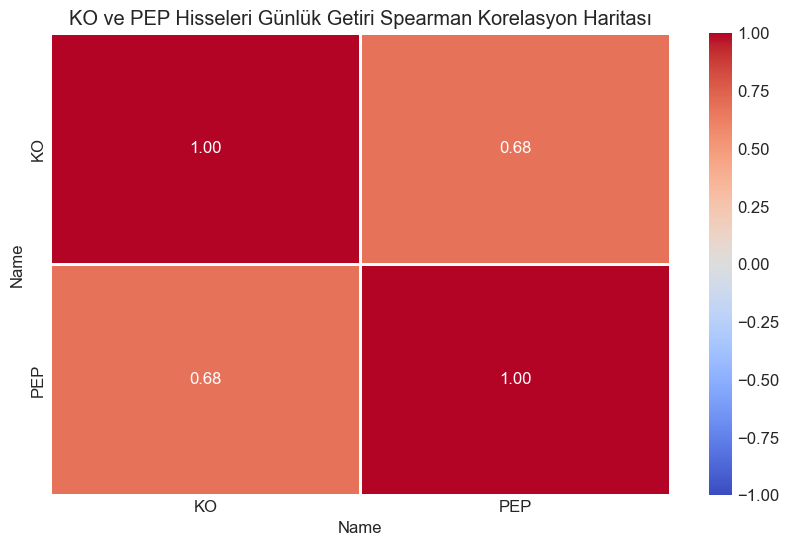

In [57]:
print("\n === Egzersiz  2: Teknoloji Hisseleri ===")
print("\n === E2a - KO ve PEP hisselerini seç günlük yüzde getiri sütınu oluştur ve Pearson korelasyonunu hesapla ===")

cola_stocks = stocks[stocks['Name'].isin(['KO', 'PEP'])]
cola_pivot = cola_stocks.pivot(index='date', columns='Name', values='close')
cola_returns = cola_pivot.pct_change().dropna()
cola_corr = cola_returns.corr()
print("=== KO ve PEP Hisseleri Günlük Getiri Korelasyon Matrisi ===")
sns.heatmap(cola_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=1)
plt.title('KO ve PEP Hisseleri Günlük Getiri Korelasyon Haritası')
plt.show()

sns.heatmap(cola_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=1)
plt.title('KO ve PEP Hisseleri Günlük Getiri Korelasyon Haritası')
plt.show()

cola_sp_corr = cola_returns.corr(method='spearman')
print("=== KO ve PEP Hisseleri Günlük Getiri Spearman Korelasyon Matrisi ===")
sns.heatmap(cola_sp_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=1)
plt.title('KO ve PEP Hisseleri Günlük Getiri Spearman Korelasyon Haritası')
plt.show()

### Egzersiz 2a Cevap:
> Çok yüksek korelasyonlu hisseler seçmek portföy riskini artırır.

#### Formüle Göre Neden Artar?
* Yüksek Korelasyon: Hisseler aynı yönde hareket eder.
* Pozitif Kovaryans: \(Cov(X,Y)\) terimi pozitif ve büyüktür.
* Maksimum Varyans: Formüldeki \(2Cov(X,Y)\) değeri toplamı yükseltir.
* Sıfır Koruma: Bir hisse düşerken diğeri de düşer.

### Çeşitlendirme (Diversification) Nedir?
> * Çeşitlendirme, finansal riskleri yayma stratejisidir. 
* "Tüm yumurtaları aynı sepete koymamak" anlamına gelir.
* Düşük veya negatif korelasyonlu varlıklar seçilir.
* Bir sektör düşerken diğeri portföyü dengeler.
* Toplam portföy dalgalanması minimuma iner.Getiri potansiyeli korunurken risk azaltılır.

---
### E3 — Sağlık ve Confounding (Karıştırıcı) Değişken
a) `world_health_data.csv` verisinde "Maternal Mortality" (Anne Ölüm Oranı) ile "Infant Mortality" (Bebek Ölüm Oranı) arasında çok yüksek bir pozitif korelasyon göreceksin (scatter plot çizerek doğrula). Sence bebeklerin ölmesi, annelerin ölmesine *sebep mi oluyor*? Yoksa ikisine birden sebep olan ortak bir C değişkeni mi var? Bu C değişkeni ne olabilir (Örn: GSYİH, Altyapı, Savaş)?

b) Tıpta "Simpson Paradoksu" çok yaygındır. İnternetten Simpson Paradoksu'nun ne olduğunu araştır ve "Alt gruplara ayırdığımızda (koşulladığımızda) korelasyonun YÖNÜNÜN (işaretinin) tamamen tersine dönmesi" olayını bir paragrafta açıkla.

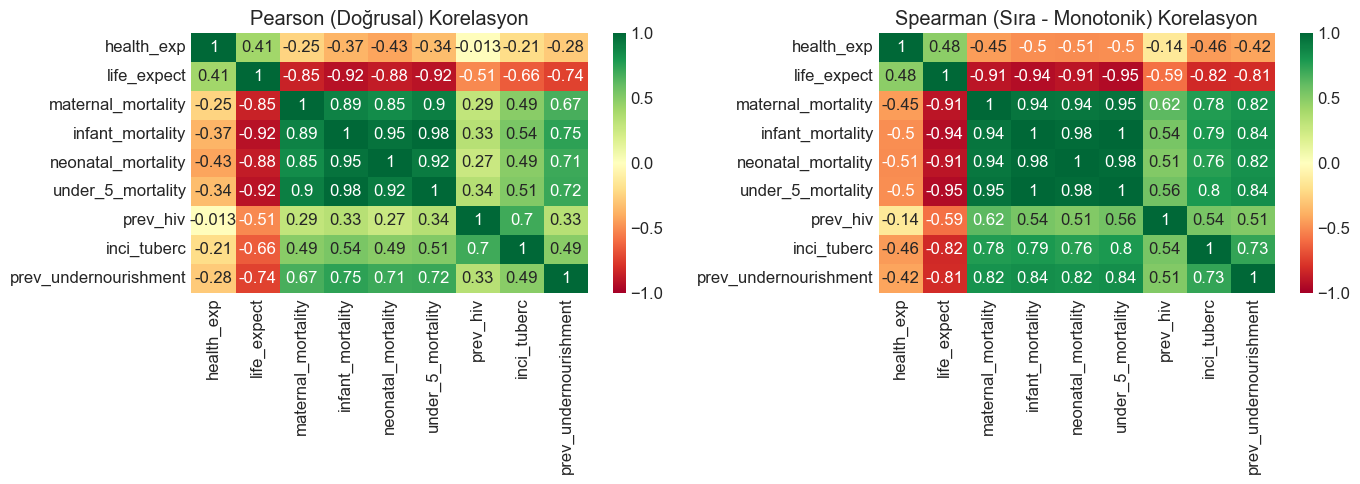

In [65]:
subset = who_df[['health_exp', 'life_expect', 'maternal_mortality', 'infant_mortality', 'neonatal_mortality', 'under_5_mortality', 'prev_hiv', 'inci_tuberc', 'prev_undernourishment']].dropna()

pearson_corr = subset.corr(method='pearson')
spearman_corr = subset.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pearson_corr, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson (Doğrusal) Korelasyon')
sns.heatmap(spearman_corr, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman (Sıra - Monotonik) Korelasyon')
plt.tight_layout()
plt.show()

### Egzersiz 1b: Simpson Paradoksu

* Simpson Paradoksu, bir popülasyondaki iki değişken arasındaki ilişkinin, popülasyon alt popülasyonlara bölündüğünde ortaya çıkması, kaybolması veya tersine dönmesiyle ilgili istatistiksel bir olgudur. 
* Örneğin, iki değişken bir popülasyonda pozitif olarak ilişkili olabilir, ancak tüm alt popülasyonlarda bağımsız veya hatta negatif olarak ilişkili olabilir. 
* Paradoksu sergileyen durumlar matematik ve olasılık teorisi açısından sorunsuz olsa da, yine de birçok insanı şaşırtmaktadır. Ayrıca, paradoks, karar teorisi, nedensel çıkarım ve evrimsel biyoloji de dahil olmak üzere olasılıklara dayanan bir dizi alan için de sonuçlar doğurmaktadır. 

> Son olarak, paradoksun anlaşılmasının verilerden doğru sonuçlar çıkarmak için gerekli olduğu epidemiyoloji ve ayrımcılık çalışmaları da dahil olmak üzere paradoksun birçok örneği vardır.

*Sprenger, Jan and Naftali Weinberger, "Simpson’s Paradox", The Stanford Encyclopedia of Philosophy (Summer 2026 Edition)*

> Örnek Grafik Görseli

![gif](data/spson.gif)

Paradoksu grafiksel olarak incelemek, paradoksun doğasını açıklığa kavuşturur. Başlangıç analizinin iki değişken, X ve Y arasında negatif bir korelasyon gösterdiği bir senaryoyu düşünün: X arttıkça Y azalır. Ancak, alt grup analizi denkleme dahil edildiğinde, X ve Y arasında aslında pozitif bir korelasyon olduğu ortaya çıkar ve başlangıçtaki gözlemle çelişir. Bu örnek, alt grup ayrımlarının göz ardı edilmesinin değişkenler arasındaki gerçek ilişkiyi nasıl bulanıklaştırabileceğini gösterir.

*[Kaynak: Simpson Paradoksu: Veri Yanılgılarını Anlamak](https://robotdreams.com.tr/blog/109-simpson-paradoksu-veri-yanilgilarini-anlamak)*

---
### E4 — SQL El Hesabı ve Log-Normal Etkisi
a) `world_health_data.csv` verisindeki `health_exp` (Sağlık Harcaması) çok sağa çarpık bir değişkendir (Zengin ülkeler uçup gitmiş - Log-Normal yapılı). SQL'de iki farklı korelasyon hesapla: 
1) $CORR(\text{health\_exp}, \text{life\_expect})$
2) $CORR(\text{LN}(\text{health\_exp}), \text{life\_expect})$ *(Doğal Logaritması alınmış haliyle)*

b) Hangi korelasyon daha yüksek çıktı? Mantıken neden LN aldığımızda korelasyon uçuşa geçti? (İpucu: Logaritma, aşırı zengin ülkelerin veriyi çekmesini engelleyip, doğrusal ilişkiye yaklaşmasını sağladı).

In [ ]:
print("==== Egzersiz 4: WHO Sağlık Verileri ====")

print("\n === E4a - Sağlık Harcaması ile Yaşam Beklentisi arasındaki Pearson Korelasyonunu SQL ile hesaplayın ===")

sql_health = con.execute("""
    SELECT
        COUNT(*) AS N,
        
        
        -- 1. Sağlık Harcaması ile Yaşam Beklentisi Pearson Korelasyonu
        ROUND(CORR(health_exp, life_expect), 4) AS pearson_corr,
        -- 2. Logaritmik Dönüşüm ile Pearson Korelasyonu
        ROUND(CORR(LOG(health_exp), life_expect), 4) AS log_pearson_corr,
        -- SQL'de doğrudan Spearman yok, ama RANK() ile elle kurabilirsin

    FROM health_tbl

""").df()

print("=== Sağlık Harcaması ve Yaşam Beklentisi Korelasyonları ===")
print(sql_health[['pearson_corr', 'log_pearson_corr']].T)


expect = who_df[['life_expect', 'health_exp']].dropna()
pearson_corr = expect.corr(method='pearson').iloc[0, 1]
who_df['log_health_exp'] = np.log(who_df['health_exp'])
pearson_corr_log = who_df[['life_expect', 'log_health_exp']].dropna().corr(method='pearson').iloc[0, 1]
print(f"Pearson Korelasyonu (Doğrusal): {pearson_corr:.4f}")
print(f"Pearson Korelasyonu (Log Dönüşümü): {pearson_corr_log:.4f}")
spearman_corr = expect.rank().corr(method='pearson').iloc[0, 1]


==== Egzersiz 4: WHO Sağlık Verileri ====

 === E4a - Sağlık Harcaması ile Yaşam Beklentisi arasındaki Pearson Korelasyonunu SQL ile hesaplayın ===
=== Sağlık Harcaması ve Yaşam Beklentisi Korelasyonları ===
                       0
pearson_corr      0.3460
log_pearson_corr  0.3714
Pearson Korelasyonu (Doğrusal): 0.3460
Pearson Korelasyonu (Log Dönüşümü): 0.3714
Spearman Korelasyonu (Sıra): 0.4514


### Egzersiz 4b Açıklama
Pearson korelasyonu sadece lineer ilişkiyi ölçüyor (notundaki 1.2'de vurguladığın nokta). Sağlık harcaması–yaşam beklentisi ilişkisi muhtemelen azalan getiri (diminishing returns) örüntüsü gösteriyor:

Düşük gelirli bir ülke sağlık harcamasını 100'den 500'a çıkardığında yaşam beklentisi büyük sıçrama yapıyor
Zengin bir ülke 5000'den 10000'e çıktığında yaşam beklentisi çok az artıyor (zaten tavana yakın)

> Bu, ham veride eğrisel (konkav) bir ilişki yaratıyor — Pearson bunu tam yakalayamıyor çünkü doğrusal değil. LN(health_exp) alındığında, bu logaritmik/azalan-getiri örüntüsü doğrusala daha yakın hale geliyor (çünkü log dönüşümü zaten üstel/logaritmik büyümeyi "düzleştirir") 

* Bu yüzden Pearson biraz daha iyi bir uyum yakalıyor.